# Lab 11 — Actividad 6: episodios de exposición

Medicamento: `sodium fluoride 0.0272 MG/MG Oral Gel`. Se consulta la base en solo lectura y se reutiliza el SQL de la Actividad 6. El histograma incluye todos los episodios de gap 30, sin recortar la cola ni transformar sus duraciones. No se implementa la Actividad 7.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

root = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "lab10/data/clinical.duckdb").is_file()
)
activity6 = (
    (root / "lab11/sql/analitica_longitudinal.sql")
    .read_text()
    .split("-- ACTIVIDAD 6", 1)[1]
)
connection = duckdb.connect(str(root / "lab10/data/clinical.duckdb"), read_only=True)
try:
    statements = connection.extract_statements("-- ACTIVIDAD 6" + activity6)
    assert len(statements) == 4
    episodes_30 = connection.execute(statements[0]).fetchdf()
    summaries = [
        connection.execute(statement).fetchdf() for statement in statements[1:]
    ]
finally:
    connection.close()

validation = pd.concat(summaries, ignore_index=True)
assert len(episodes_30) == 61159
assert episodes_30["exposure_count"].sum() == 62462
assert episodes_30["patient_id"].nunique() == 19279
assert validation["episodes"].tolist() == [61159, 58501, 56506]
assert validation["valid_exposures"].eq(62462).all()
assert validation["patients"].eq(19279).all()
validation

,gap_days,valid_exposures,patients,episodes,min_days,median_days,p90_days,p95_days,p99_days,max_days
0,30,62462.0,19279,61159,0,0.0,0.0,0.0,28.0,112
1,60,62462.0,19279,58501,0,0.0,0.0,28.0,56.0,266
2,90,62462.0,19279,56506,0,0.0,0.0,42.0,119.0,468


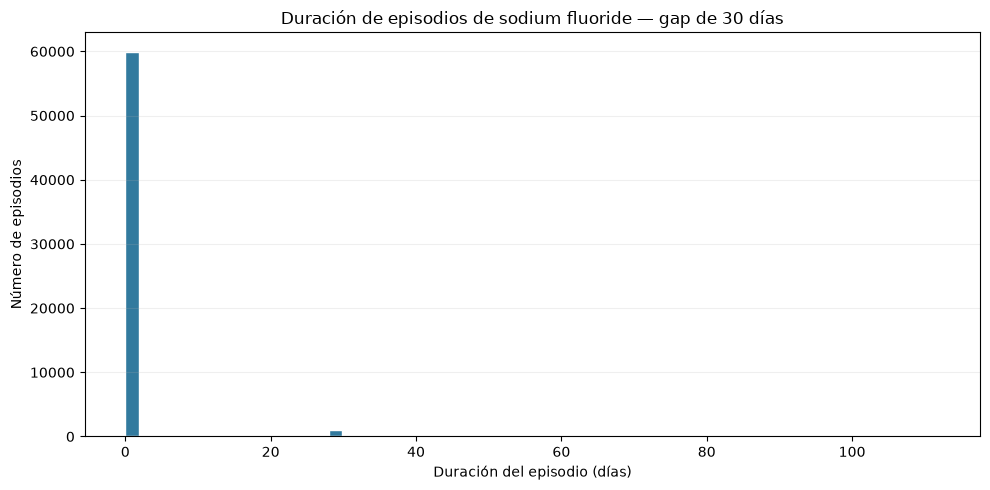

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(episodes_30["duration_days"], bins=60, color="#327a9e", edgecolor="white")
ax.set_title("Duración de episodios de sodium fluoride — gap de 30 días")
ax.set_xlabel("Duración del episodio (días)")
ax.set_ylabel("Número de episodios")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

La duración es la diferencia en días calendario entre el inicio mínimo y el fin máximo del episodio; incluye los gaps internos admitidos, no equivale a días efectivos de tratamiento. Los percentiles de la tabla anterior complementan el histograma y no excluyen observaciones.